# RAID — Baseline Detector Evaluation

This notebook runs a pretrained zero-shot detector on the RAID test set and reports:
- TPR @ 5% FPR (primary RAID metric)
- AUC-ROC
- F1, Precision, Recall
- Per-domain and per-model breakdowns
- ROC curves

**Model used:** `roberta-base-openai-detector` (OpenAI's GPT-2 detector, works as a general AI-text classifier)

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

from src.data.loader import load_raid, filter_no_attack
from src.models.baseline import ZeroShotDetector
from src.evaluation.metrics import compute_metrics, tpr_at_fpr, per_domain_metrics
from src.utils.io import save_results

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:.4f}'.format)

print('Ready.')

Ready.


## 1. Load Data

In [2]:
# test.csv labels are withheld; use a 100k-row sample of train with an 80/20 split.
TRAIN_NROWS = 100_000

train_df, _ = load_raid('../data/raw', train_nrows=TRAIN_NROWS)

from sklearn.model_selection import train_test_split
train_split, test_df = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df['label']
)
train_split = train_split.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'Train split: {len(train_split):,} rows')
print(f'Eval split:  {len(test_df):,} rows')

# Evaluate on clean (no-attack) subset of eval split
test_clean = filter_no_attack(test_df)
print(f'Clean eval subset: {len(test_clean):,} rows')
print(f'Label balance: {test_clean["label"].value_counts().to_dict()}')

Train split: 80,000 rows
Eval split:  20,000 rows
Clean eval subset: 4,693 rows
Label balance: {1: 4371, 0: 322}


In [3]:
# Optional: sub-sample for faster iteration (set to None to use all)
SAMPLE_N = 5000  # set to None for full evaluation

if SAMPLE_N and len(test_clean) > SAMPLE_N:
    eval_df = test_clean.sample(SAMPLE_N, random_state=42).reset_index(drop=True)
    print(f'Using sampled subset: {len(eval_df):,} rows')
else:
    eval_df = test_clean.reset_index(drop=True)
    print(f'Using full clean eval set: {len(eval_df):,} rows')

Using full clean eval set: 4,693 rows


## 2. Run Detector

In [4]:
# Load detector (downloads ~500 MB model on first run)
detector = ZeroShotDetector(
    model_name='roberta-base-openai-detector',
    batch_size=64,
)

texts = eval_df['generation'].tolist()
y_true = eval_df['label'].tolist()

print('Running inference...')
y_score = detector.predict_proba(texts)
y_pred  = (y_score >= 0.5).astype(int)

eval_df['y_score'] = y_score
eval_df['y_pred']  = y_pred

print('Done.')

Running inference...


config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at roberta-base-openai-detector were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use mps


Done.


## 3. Overall Metrics

In [5]:
overall = compute_metrics(y_true, y_pred, y_score, target_fpr=0.05)
print('=== Overall Metrics ===')
for k, v in overall.items():
    print(f'  {k:<25} {v:.4f}')

=== Overall Metrics ===
  accuracy                  0.5815
  precision                 0.9967
  recall                    0.5525
  f1                        0.7109
  auc                       0.8650
  tpr_at_5pct_fpr           0.6385


In [6]:
# Save results
save_results(
    overall,
    experiment_name='roberta_openai_detector_clean',
    results_dir='../results',
    extra={'model': 'roberta-base-openai-detector', 'subset': 'no_attack', 'n': len(eval_df)}
)

Results saved to ../results/roberta_openai_detector_clean_20260505_010853.json


PosixPath('../results/roberta_openai_detector_clean_20260505_010853.json')

## 4. ROC Curve

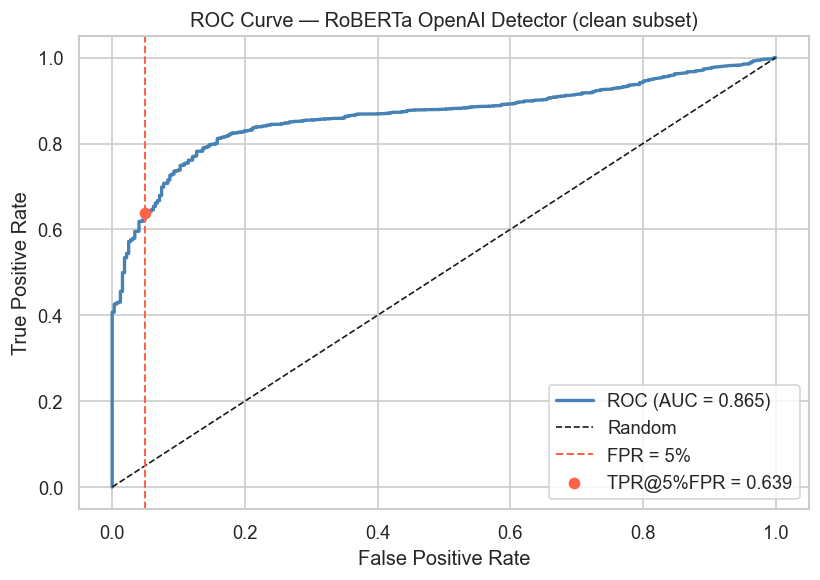

In [7]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
tpr5 = tpr_at_fpr(y_true, y_score, target_fpr=0.05)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.axvline(0.05, color='tomato', lw=1.2, linestyle='--', label='FPR = 5%')
ax.scatter([0.05], [tpr5], color='tomato', zorder=5,
           label=f'TPR@5%FPR = {tpr5:.3f}')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — RoBERTa OpenAI Detector (clean subset)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../results/roc_curve_baseline.png', bbox_inches='tight')
plt.show()

## 5. Per-Domain Breakdown

In [8]:
domain_results = per_domain_metrics(
    eval_df, y_score_col='y_score', y_pred_col='y_pred',
    label_col='label', domain_col='domain', target_fpr=0.05
)

domain_df = pd.DataFrame(domain_results).T.sort_values('tpr_at_5pct_fpr', ascending=False)
print(domain_df.to_string())

           accuracy  precision  recall     f1    auc  tpr_at_5pct_fpr
abstracts    0.5815     0.9967  0.5525 0.7109 0.8650           0.6385


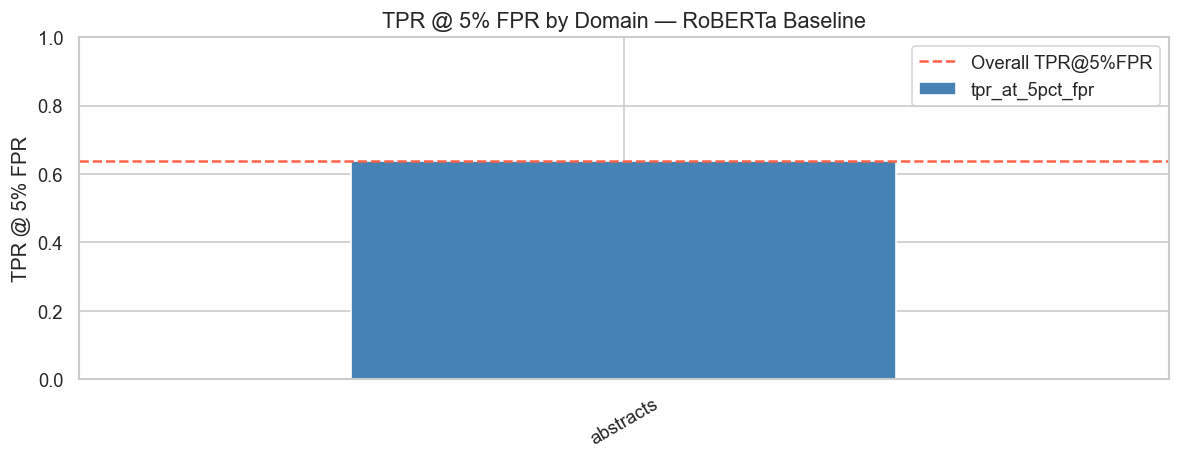

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
domain_df['tpr_at_5pct_fpr'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(overall.get('tpr_at_5pct_fpr', 0), color='tomato',
           linestyle='--', lw=1.5, label='Overall TPR@5%FPR')
ax.set_title('TPR @ 5% FPR by Domain — RoBERTa Baseline', fontsize=13)
ax.set_ylabel('TPR @ 5% FPR')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig('../results/tpr_by_domain_baseline.png', bbox_inches='tight')
plt.show()

## 6. Per-Model Breakdown

In [10]:
# Only AI rows have a meaningful model label
ai_eval = eval_df[eval_df['label'] == 1].copy()

# For per-model TPR: compare AI rows only (FPR is defined on human rows globally)
model_tpr = {}
for model, grp in ai_eval.groupby('model'):
    # Recall for each model = fraction of that model's rows detected at the global threshold
    # We use the global 5% FPR threshold derived from the full eval set
    fpr_vals, tpr_vals, thresholds = roc_curve(y_true, y_score)
    valid = fpr_vals <= 0.05
    global_threshold = thresholds[valid][-1] if valid.any() else 0.5
    detected = (grp['y_score'] >= global_threshold).mean()
    model_tpr[model] = detected

model_tpr_df = pd.Series(model_tpr).sort_values(ascending=False)
print(model_tpr_df.to_string())

mpt            0.8440
gpt2           0.8104
mistral        0.6452
llama-chat     0.5865
mistral-chat   0.5027
mpt-chat       0.4094


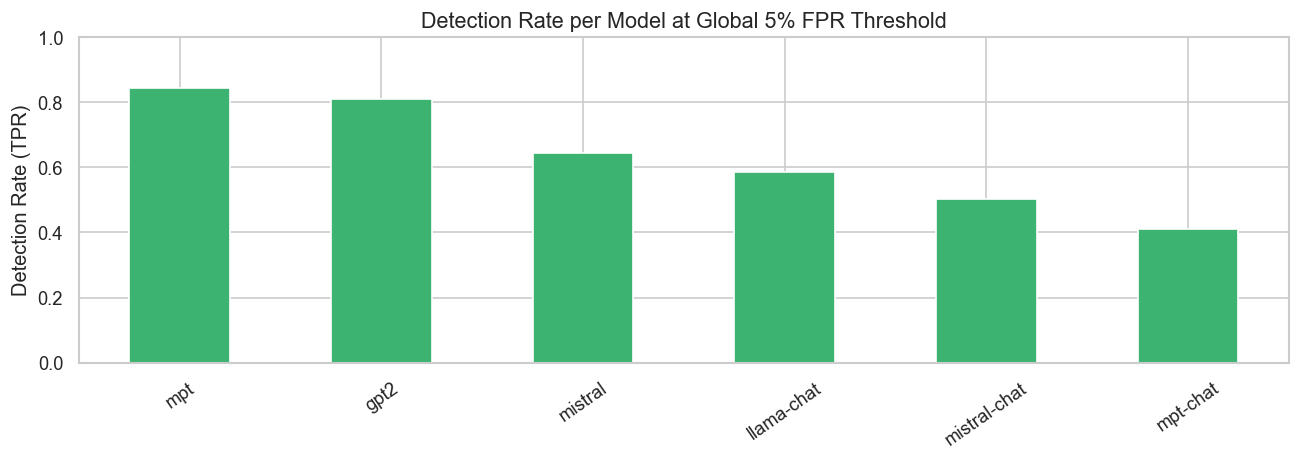

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
model_tpr_df.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Detection Rate per Model at Global 5% FPR Threshold', fontsize=13)
ax.set_ylabel('Detection Rate (TPR)')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig('../results/detection_rate_by_model_baseline.png', bbox_inches='tight')
plt.show()

## 7. Score Distribution

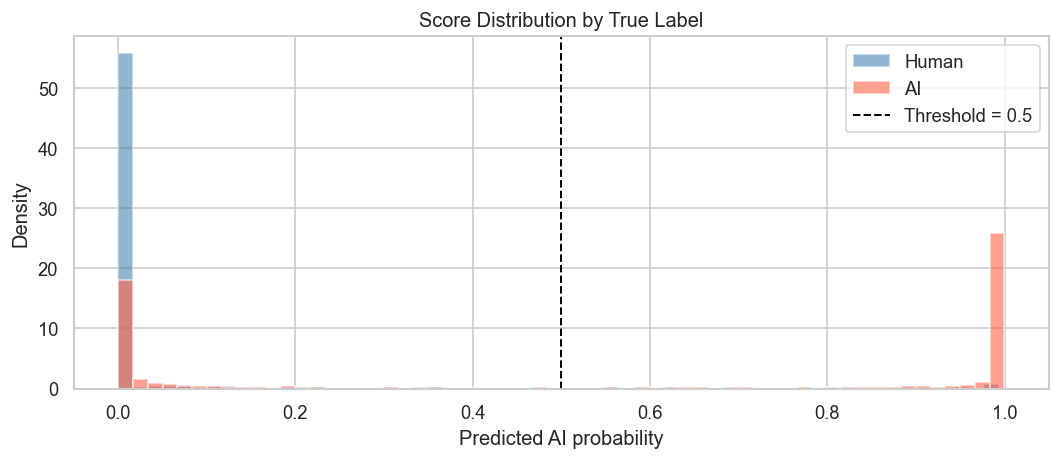

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, name, color in [(0, 'Human', 'steelblue'), (1, 'AI', 'tomato')]:
    scores = eval_df.loc[eval_df['label'] == label, 'y_score']
    ax.hist(scores, bins=60, alpha=0.6, label=name, color=color, density=True)
ax.axvline(0.5, color='black', linestyle='--', lw=1.2, label='Threshold = 0.5')
ax.set_xlabel('Predicted AI probability')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by True Label')
ax.legend()
plt.tight_layout()
plt.savefig('../results/score_distribution_baseline.png', bbox_inches='tight')
plt.show()

In [13]:
print('Baseline evaluation complete. All figures saved to ../results/')

Baseline evaluation complete. All figures saved to ../results/
